# COMSOL Full-Wave Simulation of a Coupled Quarter-Wave Resonator

::::{admonition} Required extras
:class: tip

Needs the `comsol` extra (`uv sync --extra comsol`), which installs `MPh` only. COMSOL, its license,
the RF Module, and the Design Module CAD kernel that `ProjectToFaces` needs are separate. See the
{ref}`extras reference <notebook-extras>`.
::::

The shortest path from a QPDK layout to a driven COMSOL result: build a coupled quarter-wave
resonator, put its metal into a COMSOL sheet model, add CPW ports and a frequency study, run one
adaptive driven sweep about the resonance, then solve once at its fitted minimum to export a
field on a cut plane.

## What is being modelled

A QPDK {py:func}`~qpdk.cells.quarter_wave_resonator_coupled`: a meandering coplanar-waveguide (CPW)
resonator beside a straight feedline, the standard hanger geometry for reading out superconducting
qubits {cite:p}`gopplCoplanarWaveguideResonators2008a`, whose resonance is one of the degrees of
freedom circuit QED reads a qubit through {cite:p}`blaisCircuitQuantumElectrodynamics2021`. The end
nearest the feedline is **open** and the far end **shorted**, so the line resonates at an odd
multiple of $\lambda/4$ {cite:p}`m.pozarMicrowaveEngineering2012`, and the coupling capacitor loads
the feedline into a **notch** in $|S_{21}|$.

::::{admonition} Reading the numbers on this page
:class: warning

The saved outputs come from a licensed run on one mesh. Only the frequencies COMSOL actually
solved are independent results; the rest of the sweep is a rational fit, so the curve locates the
notch but does not resolve it. PEC metal carries no conductor loss or kinetic inductance, nothing
here is shown to be mesh independent, and a fresh run on another mesh or enclosure will not
reproduce these numbers exactly.
::::

**References:**
- [COMSOL "Coplanar Waveguide Resonator" model](https://www.comsol.com/model/download/953251/models.rf.cpw_resonator.pdf)
- [COMSOL RF Module User's Guide](https://doc.comsol.com/6.3/doc/com.comsol.help.rf/RFModuleUsersGuide.pdf)
- [MPh tutorial](https://mph.readthedocs.io/en/stable/tutorial.html)

## Setup and imports

In [1]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing QPDK...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[comsol] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
    ])
    print(
        "Note: this installs the Python client only. COMSOL itself and its "
        "license are not pip-installable, so the build and solve cell below "
        "cannot run in Colab, and the result cells will report that no exported "
        "results are present."
    )

In [2]:
import os
from contextlib import suppress
from pathlib import Path

import gdsfactory as gf
import matplotlib.pyplot as plt
import numpy as np

from qpdk import PDK
from qpdk.cells.resonator import quarter_wave_resonator_coupled
from qpdk.simulation import prepare_comsol_layout
from qpdk.simulation.comsol.plotting import (
    apply_qpdk_style,
    draw_cut_plane_field,
    draw_layout_polygons,
    prefer_svg_figures,
)
from qpdk.simulation.comsol.results import (
    explain_missing_results,
    exported_frequency_ghz,
    requested_frequency_grid,
    result_file,
)
from qpdk.tech import coplanar_waveguide

try:
    import mph

    # The COMSOL class imports MPh eagerly, so it comes in with the same guard:
    # without the extra the licensed branch stays off and the rest of the
    # notebook still reads exported results back from disk.
    from qpdk.simulation import COMSOL
except ImportError:
    mph = None
    COMSOL = None

PDK.activate()

prefer_svg_figures()
STYLE_SOURCE = apply_qpdk_style()
print("Plot style: QPDK" if STYLE_SOURCE != "matplotlib defaults" else STYLE_SOURCE)

Plot style: QPDK


## Settings

The sweep is centred on the resonance the saved run found near 7.3265 GHz. `RUN_COMSOL` stays
`False`, so no solve starts by accident; the result cells below read whatever export is on disk.

In [3]:
RUN_COMSOL = False
CORES = 4

# Where a licensed run writes its exports. Without a license, point
# QPDK_COMSOL_RESULTS_DIR at a directory holding an exported run and the result
# cells below replot it.
MODEL_DIR = Path.home() / "comsol_models"
RESULTS_DIR_ENV = "QPDK_COMSOL_RESULTS_DIR"
_env_results_dir = os.environ.get(RESULTS_DIR_ENV)
RESULTS_DIR: Path | None = (
    Path(_env_results_dir).expanduser()
    if _env_results_dir
    else MODEL_DIR
    if RUN_COMSOL
    else None
)

CPW_WIDTH_UM = 10.0
CPW_GAP_UM = 6.0
GROUND_MARGIN_UM = 1200.0
LEFT_EXTENSION_UM = 1320.0
RIGHT_EXTENSION_UM = 2000.0

# One mesh, one enclosure: absolute sizes in µm, with a tighter size on the
# meander edges where the mode's field concentrates.
SUBSTRATE_THICKNESS_UM = 200.0
AIR_HEIGHT_UM = 200.0
SILICON_RELATIVE_PERMITTIVITY = 11.7
MESH_SIZE = 2
GLOBAL_HMAX_UM = 100.0
GLOBAL_HMIN_UM = 2.0
EDGE_HMAX_UM = 4.0
EDGE_HMIN_UM = 0.4
MEANDER_EDGE_SELECTION = "meander_edges"
MEANDER_EDGE_BOX_UM = {
    "x": (-150.0, 900.0),
    "y": (-900.0, -60.0),
    "z": (-0.02, 0.02),
}
PORT_MODE_INDEX_SHIFT = 2.5

# The driven window: a fixed half-span either side of the centre, swept with
# COMSOL's adaptive frequency sweep. The request is a curve row count, not a
# number of solves.
SWEEP_CENTER_GHZ = 7.3265
SWEEP_HALF_SPAN_GHZ = 5.0e-3
SWEEP_POINTS = 101

# Field cut plane and the display crop, both in µm. A fresh solve writes the
# fixed file names; the reader also accepts an older run-tagged curve.
FIELD_CUT_Z = "1[um]"
FIELD_VIEW_UM = (-200.0, 900.0, -950.0, 150.0)
AWE_CURVE_CSV = "comsol_cpw_awe_curve.csv"
DRIVEN_FIELD_TXT = "comsol_cpw_driven_field.txt"
DRIVEN_MODEL_MPH = "comsol_cpw_resonator_driven.mph"

## Build the ported layout

The resonator is built with an explicit CPW cross-section, since the centre width and gap are
reused when describing the ports. Both feeds are extended with straight CPW so the ports land on
clean cross sections.

In [4]:
cross_section = coplanar_waveguide(width=CPW_WIDTH_UM, gap=CPW_GAP_UM)

resonator = quarter_wave_resonator_coupled(
    length=4000.0,
    meanders=4,
    cross_section=cross_section,
    cross_section_non_resonator=cross_section,
    coupling_straight_length=200.0,
    coupling_gap=20.0,
)

component = gf.Component(name="comsol_cpw_resonator")
component << resonator

left_straight = component << gf.components.straight(
    length=LEFT_EXTENSION_UM, cross_section=cross_section
)
right_straight = component << gf.components.straight(
    length=RIGHT_EXTENSION_UM, cross_section=cross_section
)
left_straight.connect("o2", resonator.ports["coupling_o1"])
right_straight.connect("o1", resonator.ports["coupling_o2"])
component.add_port("input", port=left_straight.ports["o1"])
component.add_port("output", port=right_straight.ports["o2"])

DPort(self.name='output', self.width=10.0, trans=r0 *1 2200,0, layer=M1_DRAW (1/0), port_type=optical)

In [5]:
layout = prepare_comsol_layout(
    component,
    feed_ports=("input", "output"),
    ground_margin=GROUND_MARGIN_UM,
    crop_to_feed_ports=True,
)
print(
    f"Metal polygons: {len(layout.polygons)}, prepared bounding box (µm): {layout.bbox}"
)

Metal polygons: 3, prepared bounding box (µm): ComsolBoundingBox(xmin=-1320.0, ymin=-2041.0, xmax=2200.0, ymax=1211.0)


One ground plane with a single hole: the CPW channel, carrying the centre strip, both etch gaps, and
the surrounding ground. Keeping the hole is what makes `ProjectToFaces` necessary, so the etched
region stays open in the sheet.

findfont: Failed to find font weight bold, now using 400.


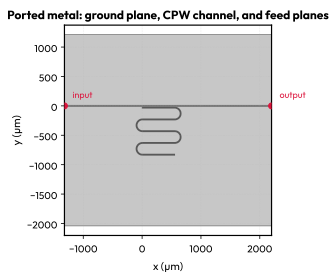

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
draw_layout_polygons(ax, layout.polygons)
for feed in layout.feed_ports:
    ax.plot(*feed.center, marker="o", color="crimson", markersize=6, zorder=4)
    ax.annotate(
        feed.name,
        feed.center,
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=9,
        color="crimson",
    )
ax.set_aspect("equal")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_title("Ported metal: ground plane, CPW channel, and feed planes")
plt.tight_layout()
plt.show()

## Build and solve the driven model

{py:class}`~qpdk.simulation.comsol.model.COMSOL` builds the air, silicon, and metal sheet, and
{py:meth}`~qpdk.simulation.comsol.model.COMSOL.add_cpw_rf_study` adds PEC metal, two CPW ports
with their boundary mode analysis steps, and a frequency study. The meander edges then get a
tighter absolute element size before the adaptive sweep. A direct solve at the fitted minimum
supplies the field export. The saved run used silicon $\varepsilon_\text{r} = 11.7$.

The step below is off by default. Run it on a licensed machine to build, mesh, solve, save an
`.mph`, write the curve CSV, and export the field.

In [7]:
def create_meander_edge_selection(model) -> list[int]:
    """Create the named meander edge selection on ``comp1`` and check it.

    The box takes edges with a vertex inside it, which reaches the trace and gap
    outlines crossing the meander stripe.

    Returns:
        The edge entities the box resolved to.

    Raises:
        RuntimeError: If the box resolves to no edge.
    """
    component = model.java.component("comp1")
    component.selection().create(MEANDER_EDGE_SELECTION, "Box")
    selection = component.selection(MEANDER_EDGE_SELECTION)
    # entitydim is a string: an int makes JPype pick the numeric set() overload.
    selection.set("entitydim", "1")
    selection.set("condition", "somevertex")
    for axis, (low, high) in MEANDER_EDGE_BOX_UM.items():
        selection.set(f"{axis}min", f"{low:g}")
        selection.set(f"{axis}max", f"{high:g}")
    edges = sorted(int(entity) for entity in selection.entities())
    if not edges:
        raise RuntimeError("the meander edge box selected no edge")
    return edges


def solve_driven(client) -> None:
    """Build, mesh, solve, and export the driven model into ``MODEL_DIR``.

    Raises:
        RuntimeError: If the mesh produces no elements, or the model reports no
            default dataset to read the frequency solution from.
    """
    model = COMSOL.create_sheet(
        client,
        layout,
        name="QPDK coupled quarter-wave resonator, driven",
        substrate_thickness_um=SUBSTRATE_THICKNESS_UM,
        air_height_um=AIR_HEIGHT_UM,
        silicon_relative_permittivity=SILICON_RELATIVE_PERMITTIVITY,
    )
    try:
        model.add_cpw_rf_study(
            cpw_gap_um=CPW_GAP_UM,
            frequency_ghz=SWEEP_CENTER_GHZ,
            mesh_size=MESH_SIZE,
            effective_index_shift=PORT_MODE_INDEX_SHIFT,
        )
        create_meander_edge_selection(model)
        elements = model.pin_absolute_edge_mesh_sizes(
            edge_selection=MEANDER_EDGE_SELECTION,
            global_hmax_um=GLOBAL_HMAX_UM,
            global_hmin_um=GLOBAL_HMIN_UM,
            edge_hmax_um=EDGE_HMAX_UM,
            edge_hmin_um=EDGE_HMIN_UM,
        )
        if elements == 0:
            raise RuntimeError("the mesh produced no elements")
        print(f"Mesh: {elements:,} elements")

        expression, _ = requested_frequency_grid(
            SWEEP_CENTER_GHZ - SWEEP_HALF_SPAN_GHZ,
            SWEEP_CENTER_GHZ + SWEEP_HALF_SPAN_GHZ,
            SWEEP_POINTS,
        )
        study = model.java.study("std1")
        step = study.feature("freq")
        step.set("plist", expression)
        step.set("awe", "on")
        step.set("awefunc", ["abs(comp1.emw.S11)"])
        study.run()
        for problem in model.problems():
            print(f"  solver reports: {problem}")

        # A ported study holds boundary mode datasets as well, so the frequency
        # solution is read from the default dataset, not the first tag.
        evaluation = (model / "evaluations").create("Eval")
        try:
            dataset_tag = str(evaluation.property("data"))
        finally:
            with suppress(Exception):
                evaluation.remove()
        dataset = next(
            (node for node in model / "datasets" if node.tag() == dataset_tag), None
        )
        if dataset is None:
            raise RuntimeError(f"the model holds no dataset tagged {dataset_tag!r}")

        frequency_ghz = (
            np.atleast_1d(model.evaluate("freq", dataset=dataset)).ravel().real / 1e9
        )
        s21_db = (
            np.atleast_1d(model.evaluate("emw.S21dB", dataset=dataset)).ravel().real
        )
        s11_db = (
            np.atleast_1d(model.evaluate("emw.S11dB", dataset=dataset)).ravel().real
        )
        order = np.argsort(frequency_ghz)
        (MODEL_DIR / DRIVEN_FIELD_TXT).unlink(missing_ok=True)
        np.savetxt(
            MODEL_DIR / AWE_CURVE_CSV,
            np.column_stack([
                frequency_ghz[order],
                s21_db[order],
                s11_db[order],
            ]),
            delimiter=",",
            header="frequency_ghz,s21_db,s11_db",
            comments="",
        )

        # AWE rows include fitted values; solve the fitted minimum directly
        # before exporting its field.
        field_frequency_ghz = float(frequency_ghz[np.argmin(s21_db)])
        step.set("awe", "off")
        step.set("plist", f"{field_frequency_ghz:.12g}[GHz]")
        study.run()
        result = model.java.result()
        cut = result.dataset().create("fieldcut", "CutPlane")
        cut.set("data", dataset.tag())
        cut.set("planetype", "quick")
        cut.set("quickplane", "xy")
        cut.set("quickz", FIELD_CUT_Z)
        export = result.export().create("field1", "Data")
        export.set("data", "fieldcut")
        export.set("expr", ["emw.normE"])
        export.set("innerinput", "manual")
        export.set("solnum", "1")
        export.set("filename", str(MODEL_DIR / DRIVEN_FIELD_TXT))
        export.run()

        model.save(MODEL_DIR / DRIVEN_MODEL_MPH)
        print(
            f"Wrote {AWE_CURVE_CSV}, {DRIVEN_FIELD_TXT} at "
            f"{field_frequency_ghz:.6f} GHz, and "
            f"{DRIVEN_MODEL_MPH} to {MODEL_DIR}"
        )
    finally:
        client.remove(model)


if RUN_COMSOL:
    if mph is None or COMSOL is None:
        raise RuntimeError("RUN_COMSOL needs MPh and a licensed COMSOL installation")
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    client = mph.start(cores=CORES)
    solve_driven(client)
    client.clear()
else:
    print(
        "The licensed solve is off by default. Set RUN_COMSOL = True on a machine "
        "with COMSOL and its license to build, mesh, solve, and export the driven "
        "model; the cells below then read those exports from MODEL_DIR."
    )

The licensed solve is off by default. Set RUN_COMSOL = True on a machine with COMSOL and its license to build, mesh, solve, and export the driven model; the cells below then read those exports from MODEL_DIR.


## Saved S21 curve

The curve below reads an export from the licensed step or a saved run. Its line is the adaptive
sweep's rational fit: most rows are interpolation between the frequencies COMSOL actually solved,
so the curve locates the notch but does not resolve it. The run that produced it was more
controlled than a fresh single solve, and a rerun on another mesh or machine will differ in detail.

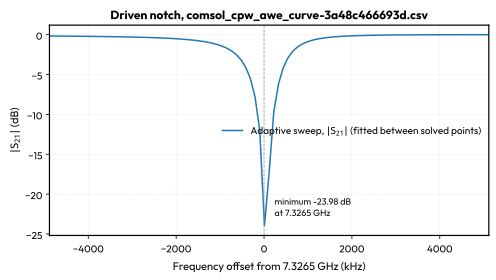

In [8]:
curve_path = result_file(RESULTS_DIR, AWE_CURVE_CSV)
if curve_path is None and RESULTS_DIR is not None:
    # Older runs tagged the curve with their run ID instead of the fixed name.
    tagged = sorted(
        RESULTS_DIR.glob("comsol_cpw_awe_curve-*.csv"),
        key=lambda path: path.stat().st_mtime,
    )
    curve_path = tagged[-1] if tagged else None

if curve_path is None:
    print(explain_missing_results(RESULTS_DIR, AWE_CURVE_CSV))
else:
    curve = np.atleast_1d(np.genfromtxt(curve_path, delimiter=",", names=True))
    frequency_ghz = np.asarray(curve["frequency_ghz"], dtype=float)
    s21_db = np.asarray(curve["s21_db"], dtype=float)
    minimum_index = int(np.argmin(s21_db))
    offset_khz = (frequency_ghz - SWEEP_CENTER_GHZ) * 1e6

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(
        offset_khz,
        s21_db,
        color="C0",
        label=r"Adaptive sweep, $|S_{21}|$ (fitted between solved points)",
    )
    ax.axvline(0.0, color="0.6", linewidth=0.8, linestyle="--")
    ax.annotate(
        f"minimum {s21_db[minimum_index]:+.2f} dB\nat {frequency_ghz[minimum_index]:.4f} GHz",
        (offset_khz[minimum_index], s21_db[minimum_index]),
        textcoords="offset points",
        xytext=(10, 10),
        fontsize=9,
    )
    ax.set_xlabel(f"Frequency offset from {SWEEP_CENTER_GHZ:g} GHz (kHz)")
    ax.set_ylabel(r"$|S_{21}|$ (dB)")
    ax.set_title(f"Driven notch, {curve_path.name}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Saved driven field map

`emw.normE` on a cut plane 1 µm above the metal, from a direct solve at the fitted minimum. The export's header names
the frequency the field was solved at, so the title says which solution it shows. The amplitude
follows the solver's drive normalization, so the colour scale gives relative shape rather than a
field strength at a stated input power. The figure crops to the coupling section, the meander, and
the feedline, and for display only draws a fixed-stride subset of the cropped nodes.

In [9]:
field_path = result_file(RESULTS_DIR, DRIVEN_FIELD_TXT)
if field_path is None:
    print(explain_missing_results(RESULTS_DIR, DRIVEN_FIELD_TXT))
else:
    field_frequency_ghz = exported_frequency_ghz(field_path)
    draw_cut_plane_field(
        field_path,
        f"Driven $|\\mathbf{{E}}|$ at {field_frequency_ghz:g} GHz, z = 1 µm"
        if field_frequency_ghz is not None
        else "Driven $|\\mathbf{E}|$ at z = 1 µm",
        view_um=FIELD_VIEW_UM,
        stride=4,
        contour_levels=30,
    )

Field nodes: 55396 of 75314 inside the view; 13849 drawn at stride 4; range 873 to 3.12e+08 V/m, 1st to 99th percentile 2.84e+04 to 2.22e+08 V/m


The field sits on the meander and is weak on the feedline, which is what a mode localised on the
resonator looks like. Localisation is not the quarter-wave condition, and one cut plane from one
solve is a consistency check on the field, not a convergence result.

## Summary

A scripted path from a QPDK layout through a sheet model to a driven $S_{21}$ notch and a field map,
all on one mesh. The notch depth comes from the coupling plus whatever loss the model carries, and
PEC adds no conductor or dielectric loss. This is a demonstration of the workflow, not a converged
model or a device prediction.

### Next steps

- Refine the mesh and check whether the notch frequency and depth move.
- Fit a quality factor from the notch width, after confirming the sweep resolves it.
- Replace the outer PEC walls with scattering boundaries, and PEC with a surface-impedance condition.

## References

```{bibliography}
:filter: docname in docnames
```